# ENG2440 Assignment 1 — Pneumonia Classification Challenge
**Name:** Yintong Wang  **Student ID:** 2501183 **GitHub repo:** …

Skeleton only: headings follow the marking rubric, and every `TODO` is yours to write.
AI use is recorded in `ai_use_declaration.txt`.

## 0. Configuration and reproducibility

In [38]:
from pathlib import Path

# Change only DATA_ROOT (assignment §9, step 4)
DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [39]:
# Dataset verification (copied from assignment §9, step 5)
dicom_files = list(DATA_ROOT.rglob("*.dcm"))

print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())

assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [40]:
# Imports
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

# pick the best available device: cuda > mps (apple silicon) > cpu
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

SEEDS = [0, 1, 2]   # §E: at least three seeds for the headline configuration
print("Using device:", device)

Using device: mps


## A. Define the task and inspect the data (8 marks)
### A1. Input, output and clinical question [2]
*TODO (your own words):* what goes in, what comes out, and what clinical question it answers.
Include both limitations: (1) a **negative label is not the same as a normal image**; (2) the labels are **expert annotations of *possible* pneumonia**, a proxy for the real condition, not confirmed diagnoses.

ANSWER: The input is a DICOM image of frontal chest radiograph. The output is a binary prediction, deciding whether the image classification is consistent with pneumonia or not.

The clinical question is that given a chest X-ray image could this patient have pneumonia and does it require further clinical review.

Limitation 1: A negative label does not necessarily mean that an image is normal, since it only suggests that the image does not fit critirias of pneumonia. 

Limitation 2: The images does not equate to ground truth.

### A2. Load labels and mapping, then collapse to one label per examination [3]

In [41]:
# read LABEL_FILE and MAPPING_FILE

labels_df = pd.read_csv(LABEL_FILE)
mapping_df = pd.read_csv(MAPPING_FILE)

# collapse repeated rows by patientId -> y = 1 if ANY row has Target == 1
exam_df = labels_df.groupby("patientId", as_index=False)["Target"].max() # each examination can have multiple bounding-box rows when Target == 1

# left-join (merge) the mapping on patientId from 
exam_df = exam_df.merge(mapping_df, on="patientId", how="left")

# keep only exams that have a matching .dcm under DATA_ROOT.
# Full DATA_ROOT -> exam_df unchanged. Subsample DATA_ROOT -> filtered to the 2500-exam stratified subsample used here for compute time reasons
# (class balance preserved: see printed pos_frac below).
available_ids = {p.stem for p in DATA_ROOT.rglob("*.dcm")}
exam_df = exam_df[exam_df["patientId"].isin(available_ids)].reset_index(drop=True)

print("Exams available under DATA_ROOT:", len(exam_df))
print("Positive fraction:", exam_df["Target"].mean())


# report: unique examinations, unique nih_patient_id, class counts and proportions
n_exams = exam_df["patientId"].nunique()
n_patients = exam_df["nih_patient_id"].nunique()
class_counts = exam_df["Target"].value_counts().sort_index()
class_props = exam_df["Target"].value_counts(normalize=True).sort_index()

print("Unique examinations:", n_exams)
print("Unique nih_patient_id:", n_patients)
print("Class counts:", class_counts)
print("Class proportions:", class_props)

Exams available under DATA_ROOT: 25684
Positive fraction: 0.22033172403052484
Unique examinations: 25684
Unique nih_patient_id: 11171
Class counts: Target
0    20025
1     5659
Name: count, dtype: int64
Class proportions: Target
0    0.779668
1    0.220332
Name: proportion, dtype: float64


### A3. Representative images, at least 6 (positive, negative, at least 1 difficult or unusual) [2]

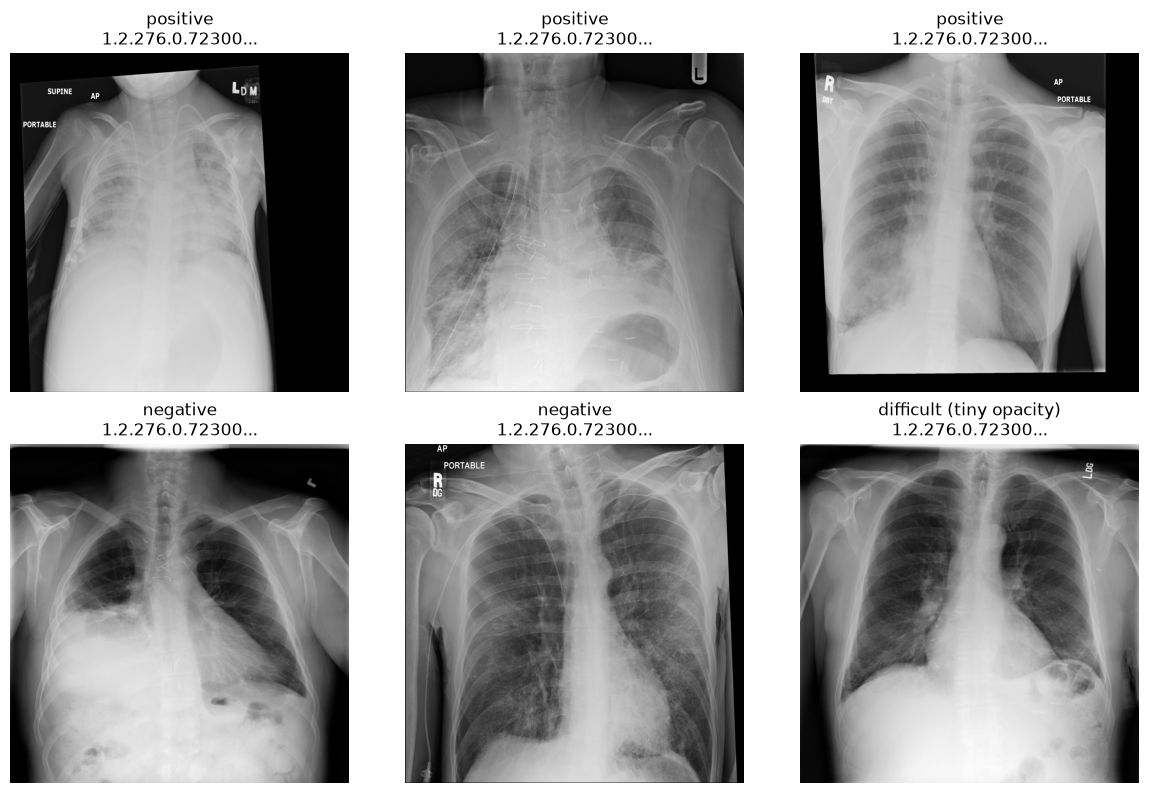

In [42]:
# The dcm files are named after SOPInstanceUID, which is the same as patientId in the labels csv 
# use the filename to find the right file for each id.
id_to_path = {}
for p in dicom_files:
    id_to_path[p.stem] = p

positive_ids = exam_df[exam_df["Target"] == 1]["patientId"].tolist()
negative_ids = exam_df[exam_df["Target"] == 0]["patientId"].tolist()

# random selection
random.seed(0)
some_positives = random.sample(positive_ids, 3)
some_negatives = random.sample(negative_ids, 2)

# difficult example: a positive case where the bounding box is very small.
# restrict to patientIds actually available under DATA_ROOT (exam_df is
# already filtered to that set), otherwise this can pick an exam whose
# .dcm isn't present -- e.g. when DATA_ROOT points at the subsample.
labels_df["box_area"] = labels_df["width"] * labels_df["height"]
positive_rows = labels_df[
    (labels_df["Target"] == 1) & (labels_df["patientId"].isin(positive_ids))
]
hard_row = positive_rows.sort_values("box_area").iloc[0]
hard_id = hard_row["patientId"]

ids_to_show = some_positives + some_negatives + [hard_id]
titles = ["positive"] * 3 + ["negative"] * 2 + ["difficult (tiny opacity)"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, pid, title in zip(axes.flatten(), ids_to_show, titles):
    img = pydicom.dcmread(id_to_path[pid]).pixel_array.astype(np.float32)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{title}\n{pid[:15]}...")
    ax.axis("off")

plt.tight_layout()
plt.show()

### A4. Image size, PhotometricInterpretation, ViewPosition (AP/PA) [1]

In [43]:
# TODO: read these DICOM header fields and summarise them (e.g. value_counts)

rows = []
for f in dicom_files:
    dcm = pydicom.dcmread(f, stop_before_pixels=True) # Skip the pixels and only read the header
    rows.append(
        {
            "rows": getattr(dcm, "Rows", None),
            "columns": getattr(dcm, "Columns", None),
            "photometric": getattr(dcm, "PhotometricInterpretation", None),
            "view_position": getattr(dcm, "ViewPosition", None),
        }
    )

header_df = pd.DataFrame(rows)

print("Image size: ", header_df.groupby(["rows", "columns"]).size())
print(header_df.groupby(["rows", "columns"]).size())
print("PhotometricInterpretation:")
print(header_df["photometric"].value_counts())
print("ViewPosition:")
print(header_df["view_position"].value_counts())



Image size:  rows  columns
1024  1024       25684
dtype: int64
rows  columns
1024  1024       25684
dtype: int64
PhotometricInterpretation:
photometric
MONOCHROME2    25684
Name: count, dtype: int64
ViewPosition:
view_position
PA    13979
AP    11705
Name: count, dtype: int64


## B. Create leakage-safe splits (10 marks)
Group by **`nih_patient_id`**, not `patientId`. Keep the test set **untouched** until final evaluation.

In [44]:
# grouped train/val/test split using nih_patient_id as the grouping unit
from sklearn.model_selection import GroupShuffleSplit

groups = exam_df["nih_patient_id"].values

# carve off 20% of patients for test (untouched until final evaluation)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
trainval_idx, test_idx = next(gss_test.split(exam_df, groups=groups))
trainval_df = exam_df.iloc[trainval_idx].reset_index(drop=True)
test_df = exam_df.iloc[test_idx].reset_index(drop=True)

# split the remaining 80% into train/val.
# test_size=0.25 = 25% of the 80% left = 20% of the original total,
# giving an overall 60% train / 20% val / 20% test split.
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx, val_idx = next(gss_val.split(trainval_df, groups=trainval_df["nih_patient_id"].values))
train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

# assert the three nih_patient_id sets are pairwise disjoint   [2]
train_patients = set(train_df["nih_patient_id"])
val_patients = set(val_df["nih_patient_id"])
test_patients = set(test_df["nih_patient_id"])

assert train_patients.isdisjoint(val_patients), "train/val patient overlap"
assert train_patients.isdisjoint(test_patients), "train/test patient overlap"
assert val_patients.isdisjoint(test_patients), "val/test patient overlap"
print("Disjointness check passed: no nih_patient_id appears in more than one split.")

# table of size + positive proportion for each split           [2]
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(df)}, n_patients={df['nih_patient_id'].nunique()}, "
          f"positive_frac={df['Target'].mean():.3f}")


Disjointness check passed: no nih_patient_id appears in more than one split.
train: n=15618, n_patients=6702, positive_frac=0.220
val: n=5082, n_patients=2234, positive_frac=0.228
test: n=4984, n_patients=2235, positive_frac=0.215


### B5. A further leakage route in multi-site data, and how you would test for it [2]
*TODO*

Since the data is collected across clinics and hospitals, they may have different marks per site, and thus it may cause bad generalization across sites.

## C. Preprocess and augment (12 marks)

### C1. DICOM → tensor, resize, intensity scaling (document your choices) [3]

In [45]:
from PIL import Image
from torchvision import transforms

IMG_SIZE = 224  # same size the pretrained CNN in part E expects

class RSNADataset(Dataset):
    # TODO: __init__, __len__, __getitem__
    def __init__(self, df, id_to_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.id_to_path = id_to_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        patient_id = row["patientId"]
        path = self.id_to_path[patient_id]

        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)

        # MONOCHROME1 = higher value is darker (opposite of normal), so flip it
        if getattr(dcm, "PhotometricInterpretation", "MONOCHROME2") == "MONOCHROME1":
            img = img.max() - img

        # scale pixel values to 0-255 
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = (img * 255).astype(np.uint8)

        img = Image.fromarray(img, mode="L")  # L = single channel grayscale
        if self.transform is not None:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        label = torch.tensor(row["Target"], dtype=torch.float32)
        return img, label

# resize + turn into a tensor (values 0-1)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = RSNADataset(train_df, id_to_path, eval_transform)
val_dataset = RSNADataset(val_df, id_to_path, eval_transform)
test_dataset = RSNADataset(test_df, id_to_path, eval_transform)

print("train size:", len(train_dataset))
print("val size:", len(val_dataset))
print("test size:", len(test_dataset))

img0, label0 = train_dataset[0]
print("image shape:", img0.shape)
print("label:", label0.item())

train size: 15618
val size: 5082
test size: 4984
image shape: torch.Size([1, 224, 224])
label: 0.0


### C2–C3. Training-only augmentation, before/after panel, justify each transform [3+2]

TODO: 
I picked small, anatomically safe transforms:

- Random rotation (±10 degrees)
- Random translation (small shift)
- Brightness/contrast jitter


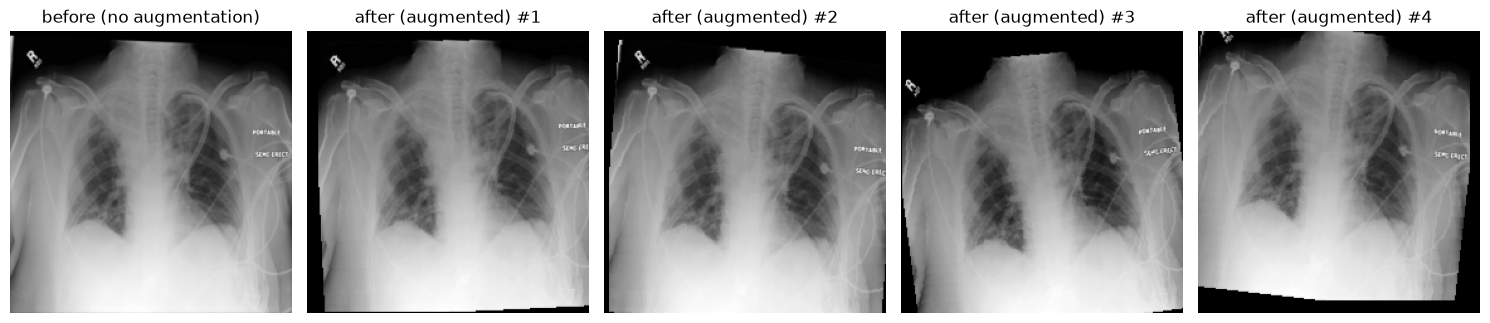

In [46]:
# train_transform = eval_transform + safe augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
]
)

# redo the training dataset with augmentation (val/test stay on eval_transform, no augmentation)
train_dataset = RSNADataset(train_df, id_to_path, train_transform)

# before/after panel: same raw image, one plain (eval_transform) vs 4 augmented versions
raw_dataset = RSNADataset(train_df, id_to_path, eval_transform)
aug_dataset = RSNADataset(train_df, id_to_path, train_transform)

# plot
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

before_img, _ = raw_dataset[0]
axes[0].imshow(before_img.squeeze(), cmap="gray")
axes[0].set_title("before (no augmentation)")
axes[0].axis("off")

for i in range(1, 5):
    after_img, _ = aug_dataset[0]  # same index, transform is random so each call looks different
    axes[i].imshow(after_img.squeeze(), cmap="gray")
    axes[i].set_title(f"after (augmented) #{i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### C4. Class imbalance strategy, evaluated with and without it [4]

In [47]:
# TODO: e.g. pos_weight in BCEWithLogitsLoss or WeightedRandomSampler, then compare metrics

n_pos = (train_df["Target"] == 1).sum()
n_neg = (train_df["Target"] == 0).sum()
pos_weight = torch.tensor(n_neg/n_pos, dtype=torch.float32)

print("n_pos:", n_pos)
print("n_neg:", n_neg)
print("pos_weight:", pos_weight.item())

# strategy 1: WITH. handle loss by weighing the positive class more
loss_fn_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# strategy 2: WITHOUT. no handling of imbalance
loss_fn_plain = nn.BCEWithLogitsLoss()

# data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

n_pos: 3430
n_neg: 12188
pos_weight: 3.5533528327941895


## D. Simple baselines (10 marks)

### D1. Trivial majority-class baseline [2]

In [48]:
# TODO

# trivial baseline: always predict the majority class (using train_df to decide which class is majority)
majority_class = train_df["Target"].mode()[0]
print("majority class:", majority_class)

# apply this constant prediction to the test set
trivial_preds = [majority_class] * len(test_df)
trivial_true = test_df["Target"].tolist()

trivial_accuracy = sum(p == t for p, t in zip(trivial_preds, trivial_true)) / len(trivial_true)
print("trivial baseline accuracy on test:", trivial_accuracy)



majority class: 0
trivial baseline accuracy on test: 0.7853130016051364


### D2–D3. nn.Linear logistic classifier on ≥4 image-summary features [5+3]
*TODO: list the exact features used.*

ANSWER: mean, std, 25% and 90% percentile.

In [49]:
# TODO: feature extraction (mean, std, percentiles)
import copy

def get_features(path):
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)

    # similar to C1, scaling
    if getattr(dcm, "PhotometricInterpretation", "MONOCHROME2") == "MONOCHROME1":
        img = img.max() - img
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255

    mean = img.mean()
    std = img.std()
    p25 = np.percentile(img, 25)
    p90 = np.percentile(img, 90)
    return [mean, std, p25, p90]

def build_feature_matrix(df):
    features = []
    labels = []
    for _, row in df.iterrows():
        path = id_to_path[row["patientId"]]
        features.append(get_features(path))
        labels.append(row["Target"])

    X = torch.tensor(features, dtype=torch.float32)
    y = torch.tensor(labels, dtype=torch.float32)

    return X, y

X_train, y_train = build_feature_matrix(train_df)
X_val, y_val = build_feature_matrix(val_df)
X_test, y_test = build_feature_matrix(test_df)

#normalize features (train only)
feat_mean = X_train.mean(dim=0)
feat_std = X_train.std(dim=0)
X_train = (X_train - feat_mean) / (feat_std + 1e-8)
X_val = (X_val - feat_mean) / (feat_std + 1e-8)
X_test = (X_test - feat_mean) / (feat_std + 1e-8)

# logistic classifier
set_seed(0)  # nn.Linear initializes weights randomly -- seed it so results are reproducible
logistic_model = nn.Linear(4, 1)
optimizer = torch.optim.Adam(logistic_model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()


best_val_loss = float("inf")
best_state = None
n_epochs = 50
for epoch in range(n_epochs):
    logistic_model.train()
    optimizer.zero_grad()
    logits = logistic_model(X_train).squeeze(1)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    logistic_model.eval()
    with torch.no_grad():
        val_logits = logistic_model(X_val).squeeze(1)
        val_loss = loss_fn(val_logits, y_val)

    # deepcopy is needed here -- state_dict() alone returns the same tensors
    # the optimizer keeps updating in-place, so without copying, best_state
    # would silently end up holding the LAST epoch's weights, not the best one
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(logistic_model.state_dict())

# TODO: train on train, tune on val, evaluate ONCE on test

logistic_model.load_state_dict(best_state)
logistic_model.eval()

with torch.no_grad():
    test_logits = logistic_model(X_test).squeeze(1)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float()


test_accuracy = (test_preds == y_test).float().mean().item()
print("logistic baseline test accuracy:", test_accuracy)

logistic baseline test accuracy: 0.7626404762268066


## E. Pretrained CNN (20 marks)

### E1. Adapt ImageNet CNN: 1-channel input and new binary head [4]
*TODO: say exactly how you handled the channel mismatch and replaced the head.*

ANSWER: ResNet18 expects 3-channel (RGB) input, but our images are 1-channel --> average them across the 3 input channels to get a single-channel version that still starts from pretrained features.

In [50]:
# TODO: build_model()
from torchvision import models

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    old_conv = model.conv1
    new_conv = nn.Conv2d(
        1, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    
    new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
    model.conv1 = new_conv

    # replace the classification head: resnet18's fc layer normally outputs
    n_features = model.fc.in_features
    model.fc = nn.Linear(n_features, 1) # 1000 ImageNet classes, we need 1 output (binary, used with BCEWithLogitsLoss)

    return model

model = build_model()
model = model.to(device)
print(model.conv1)
print(model.fc)

Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=1, bias=True)


### E2. Stage 1: fixed feature extractor. Stage 2: fine-tune at least the final conv block [5]

In [51]:
# TODO: train_one_epoch(), evaluate(), fit() — record train/val loss per epoch
import copy

def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images).squeeze(1)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images).squeeze(1)
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def fit(model, train_loader, val_loader, optimizer, loss_fn, device, n_epochs):
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(n_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = evaluate(model, val_loader, loss_fn, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # deepcopy is needed here -- state_dict() alone returns the same
        # tensors the optimizer keeps updating in-place, so without copying
        # "best_state" would silently end up holding the LAST epoch's
        # weights instead of the actual best epoch's weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        print(f"epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    # keep the best-validation-loss epoch's weights, not just the last epoch
    model.load_state_dict(best_state)
    return train_losses, val_losses

# stage 1: fix everything except for the new head
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad=False

optimizer_stage1 = torch.optim.Adam(model.fc.parameters(), lr=0.001)
train_losses_1, val_losses_1 = fit(model, train_loader, val_loader, optimizer_stage1, loss_fn_weighted, device, n_epochs = 5)

# stage 2: unfreeze the final conv block and fine-tune
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

optimizer_stage2 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)
train_losses_2, val_losses_2 = fit(model, train_loader, val_loader, optimizer_stage2, loss_fn_weighted, device, n_epochs=5)


epoch 0: train_loss=0.9096, val_loss=0.9312
epoch 1: train_loss=0.8467, val_loss=0.8262
epoch 2: train_loss=0.8407, val_loss=0.8256
epoch 3: train_loss=0.8383, val_loss=0.8256
epoch 4: train_loss=0.8325, val_loss=0.8205
epoch 0: train_loss=0.8126, val_loss=0.7932
epoch 1: train_loss=0.7363, val_loss=0.7583
epoch 2: train_loss=0.7010, val_loss=0.7429
epoch 3: train_loss=0.6753, val_loss=0.7684
epoch 4: train_loss=0.6479, val_loss=0.7507


### E4. Loss curves: underfitting or overfitting? [3]

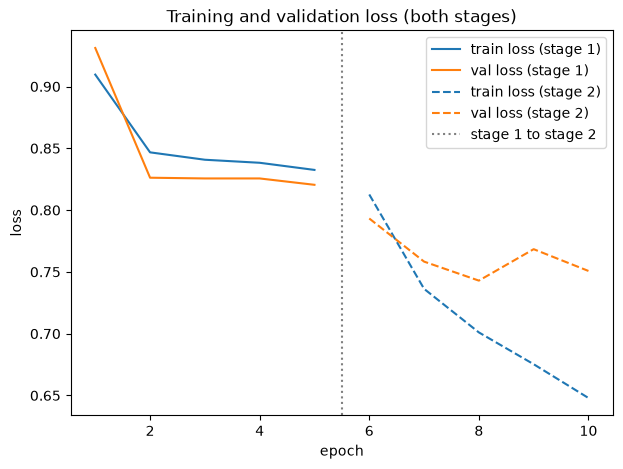

In [52]:
# TODO: plot
plt.figure(figsize=(7, 5))

# stage 1 epochs, then stage 2 epochs, plotted back to back on one timeline
epochs_stage1 = range(1, len(train_losses_1) + 1)
epochs_stage2 = range(len(train_losses_1) + 1, len(train_losses_1) + len(train_losses_2) + 1)

plt.plot(epochs_stage1, train_losses_1, label="train loss (stage 1)", color="tab:blue")
plt.plot(epochs_stage1, val_losses_1, label="val loss (stage 1)", color="tab:orange")
plt.plot(epochs_stage2, train_losses_2, label="train loss (stage 2)", color="tab:blue", linestyle="--")
plt.plot(epochs_stage2, val_losses_2, label="val loss (stage 2)", color="tab:orange", linestyle="--")

# mark where stage 2 (fine-tuning) begins
plt.axvline(x=len(train_losses_1) + 0.5, color="gray", linestyle=":", label="stage 1 to stage 2")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training and validation loss (both stages)")
plt.legend()
plt.show()



In [53]:
# shared evaluation helpers (used by both E5 seed control and part F)

def metrics_from_probs(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    accuracy = (tp + tn) / len(y_true)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

    return {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
    }

# get CNN probabilities + true labels from a loader (order matches the loader's
# dataset since shuffle=False for val_loader/test_loader)
def get_cnn_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images).squeeze(1)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(labels.numpy().tolist())
    return np.array(all_probs), np.array(all_labels)

### E5. Seed control: headline config × ≥3 seeds, mean ± std [6]
*TODO: is the CNN's gain over the baseline larger than the run-to-run variation?*

In [54]:
# TODO
seed_accuracies = []

for seed in SEEDS:
    set_seed(seed)

    model = build_model()
    model = model.to(device)

    # stage 1: frozen feature extractor
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False
    optimizer_stage1 = torch.optim.Adam(model.fc.parameters(), lr=0.001)
    fit(model, train_loader, val_loader, optimizer_stage1, loss_fn_weighted, device, n_epochs=5)

    # stage 2: fine-tune final conv block
    for name, param in model.named_parameters():
        if "layer4" in name or "fc" in name:
            param.requires_grad = True
    optimizer_stage2 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001
    )
    fit(model, train_loader, val_loader, optimizer_stage2, loss_fn_weighted, device, n_epochs=5)

    # evaluate this seed's model on test (primary metric = accuracy)
    probs, labels = get_cnn_probs(model, test_loader, device)
    seed_metrics = metrics_from_probs(labels, probs, threshold=0.5)
    seed_accuracies.append(seed_metrics["accuracy"])
    print(f"seed {seed}: test accuracy = {seed_metrics['accuracy']:.4f}")

seed_accuracies = np.array(seed_accuracies)
cnn_mean_acc = seed_accuracies.mean()
cnn_std_acc = seed_accuracies.std()

print("CNN test accuracy across seeds:", seed_accuracies)
print(f"mean = {cnn_mean_acc:.4f}, std = {cnn_std_acc:.4f}")

# is the CNN's improvement over the logistic baseline bigger than run-to-run noise?
baseline_accuracy = test_accuracy  # from D2-D3
improvement = cnn_mean_acc - baseline_accuracy
print(f"logistic baseline accuracy: {baseline_accuracy:.4f}")
print(f"CNN improvement over baseline: {improvement:.4f}")
print(f"CNN run-to-run std: {cnn_std_acc:.4f}")
print("improvement larger than std?", improvement > cnn_std_acc)



epoch 0: train_loss=0.8925, val_loss=0.8498
epoch 1: train_loss=0.8496, val_loss=0.8623
epoch 2: train_loss=0.8351, val_loss=0.8188
epoch 3: train_loss=0.8393, val_loss=0.8171
epoch 4: train_loss=0.8345, val_loss=0.8178
epoch 0: train_loss=0.8164, val_loss=0.7782
epoch 1: train_loss=0.7399, val_loss=0.7628
epoch 2: train_loss=0.7065, val_loss=0.7465
epoch 3: train_loss=0.6736, val_loss=0.7604
epoch 4: train_loss=0.6548, val_loss=0.7422
seed 0: test accuracy = 0.7819
epoch 0: train_loss=0.8867, val_loss=0.8348
epoch 1: train_loss=0.8531, val_loss=0.8562
epoch 2: train_loss=0.8402, val_loss=0.8737
epoch 3: train_loss=0.8311, val_loss=0.8453
epoch 4: train_loss=0.8417, val_loss=0.8544
epoch 0: train_loss=0.8048, val_loss=0.7838
epoch 1: train_loss=0.7330, val_loss=0.7615
epoch 2: train_loss=0.6911, val_loss=0.7830
epoch 3: train_loss=0.6772, val_loss=0.7464
epoch 4: train_loss=0.6464, val_loss=0.7694
seed 1: test accuracy = 0.8116
epoch 0: train_loss=0.8866, val_loss=0.8684
epoch 1: train

In [57]:
# C4: with-vs-without imbalance-handling comparison.
# Same architecture and same 2-stage procedure as the main CNN, but trained
# with loss_fn_plain (no pos_weight) instead of loss_fn_weighted, so the
# only thing that differs is the imbalance-handling strategy.
model_plain = build_model()
model_plain = model_plain.to(device)

# stage 1: frozen feature extractor
for name, param in model_plain.named_parameters():
    if "fc" not in name:
        param.requires_grad = False
optimizer_stage1_plain = torch.optim.Adam(model_plain.fc.parameters(), lr=0.001)
fit(model_plain, train_loader, val_loader, optimizer_stage1_plain, loss_fn_plain, device, n_epochs=5)

# stage 2: fine-tune final conv block
for name, param in model_plain.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
optimizer_stage2_plain = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_plain.parameters()), lr=0.0001
)
fit(model_plain, train_loader, val_loader, optimizer_stage2_plain, loss_fn_plain, device, n_epochs=5)

# evaluate on test, same way as the weighted CNN
plain_test_probs, plain_test_labels = get_cnn_probs(model_plain, test_loader, device)
plain_metrics = metrics_from_probs(plain_test_labels, plain_test_probs, threshold=0.5)

# also compute the weighted CNN's test metrics here (not just in part F),
# so this cell doesn't depend on the later F cell having already run
weighted_test_probs, weighted_test_labels = get_cnn_probs(model, test_loader, device)
weighted_metrics = metrics_from_probs(weighted_test_labels, weighted_test_probs, threshold=0.5)

print("CNN WITHOUT imbalance handling (plain loss) test metrics:", plain_metrics)
print("CNN WITH imbalance handling (pos_weight) test metrics:", weighted_metrics)

epoch 0: train_loss=0.4486, val_loss=0.4274
epoch 1: train_loss=0.4220, val_loss=0.4156
epoch 2: train_loss=0.4206, val_loss=0.4277
epoch 3: train_loss=0.4181, val_loss=0.4363
epoch 4: train_loss=0.4161, val_loss=0.4135
epoch 0: train_loss=0.4075, val_loss=0.3875
epoch 1: train_loss=0.3691, val_loss=0.3748
epoch 2: train_loss=0.3526, val_loss=0.3803
epoch 3: train_loss=0.3422, val_loss=0.3833
epoch 4: train_loss=0.3250, val_loss=0.3885
CNN WITHOUT imbalance handling (plain loss) test metrics: {'TP': 501, 'TN': 3690, 'FP': 224, 'FN': 569, 'accuracy': 0.8408908507223114, 'sensitivity': 0.46822429906542057, 'specificity': 0.942769545222279, 'precision': 0.6910344827586207, 'f1': 0.5582172701949861}
CNN WITH imbalance handling (pos_weight) test metrics: {'TP': 838, 'TN': 3032, 'FP': 882, 'FN': 232, 'accuracy': 0.7764847512038523, 'sensitivity': 0.7831775700934579, 'specificity': 0.7746550843127236, 'precision': 0.4872093023255814, 'f1': 0.6007168458781362}


## F. Evaluate performance (15 marks)

CNN test metrics: {'TP': 838, 'TN': 3032, 'FP': 882, 'FN': 232, 'accuracy': 0.7764847512038523, 'sensitivity': 0.7831775700934579, 'specificity': 0.7746550843127236, 'precision': 0.4872093023255814, 'f1': 0.6007168458781362}
               model  accuracy  sensitivity  specificity  precision        f1
0   trivial baseline  0.785313     0.000000     1.000000   0.000000  0.000000
1  logistic baseline  0.762640     0.021495     0.965253   0.144654  0.037429
2                CNN  0.776485     0.783178     0.774655   0.487209  0.600717


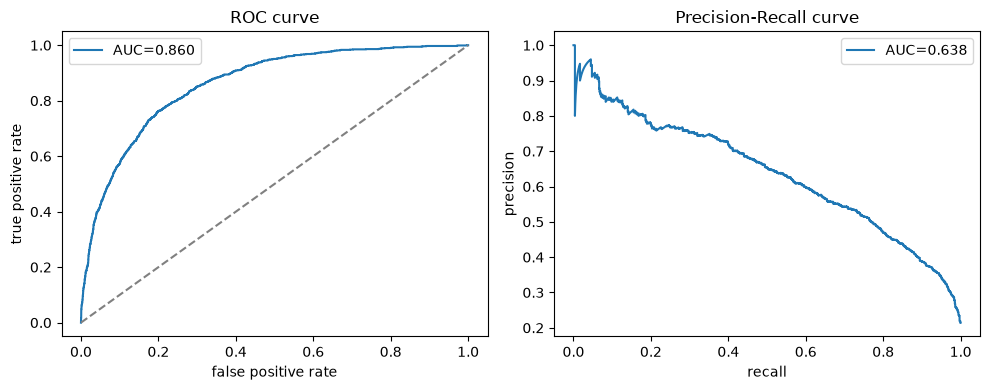

ROC AUC: 0.8598603622748915
PR AUC: 0.6382458925395859
screening threshold (chosen on val): 0.3
high-specificity threshold (chosen on val): 0.99
screening threshold applied to test: {'TP': 953, 'TN': 2480, 'FP': 1434, 'FN': 117, 'accuracy': 0.6888041733547352, 'sensitivity': 0.8906542056074767, 'specificity': 0.633622892181911, 'precision': 0.39924591537494764, 'f1': 0.5513450969048307}
high-specificity threshold applied to test: {'TP': 14, 'TN': 3913, 'FP': 1, 'FN': 1056, 'accuracy': 0.7879213483146067, 'sensitivity': 0.013084112149532711, 'specificity': 0.9997445068983137, 'precision': 0.9333333333333333, 'f1': 0.025806451612903226}


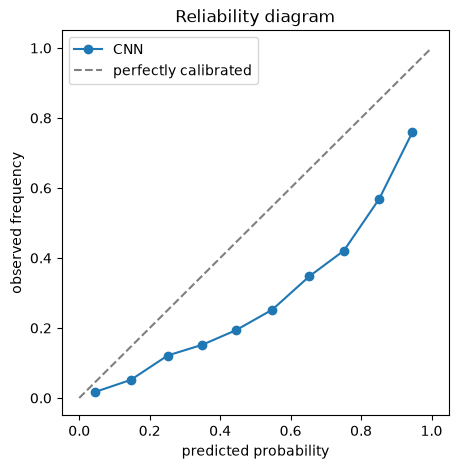

In [55]:
# TODO: metrics_from_probs(y_true, y_prob, threshold) -> confusion matrix, acc, sens, spec, precision, F1   [3]
# (metrics_from_probs and get_cnn_probs are defined earlier, right before E5,
# since E5's seed loop needs them too)

cnn_val_probs, cnn_val_labels = get_cnn_probs(model, val_loader, device)
cnn_test_probs, cnn_test_labels = get_cnn_probs(model, test_loader, device)

cnn_metrics = metrics_from_probs(cnn_test_labels, cnn_test_probs, threshold=0.5)
print("CNN test metrics:", cnn_metrics)


# TODO: ONE comparison table: trivial vs simple baseline vs CNN (same splits and metrics)                [3]
# trivial baseline "probability" is just the constant majority_class for every test exam
trivial_probs = np.full(len(test_df), majority_class, dtype=float)
trivial_metrics = metrics_from_probs(test_df["Target"].values, trivial_probs, threshold=0.5)

# logistic baseline probabilities were already computed in D2-D3 (test_probs, y_test)
logistic_metrics = metrics_from_probs(y_test.numpy(), test_probs.numpy(), threshold=0.5)

# same list-of-tuples pattern used in part B for the split summary
comparison_rows = []
for model_name, m in [("trivial baseline", trivial_metrics),
                       ("logistic baseline", logistic_metrics),
                       ("CNN", cnn_metrics)]:
    comparison_rows.append({
        "model": model_name,
        "accuracy": m["accuracy"],
        "sensitivity": m["sensitivity"],
        "specificity": m["specificity"],
        "precision": m["precision"],
        "f1": m["f1"],
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df)


# TODO: ROC + PR curves with AUCs; which is more informative under this imbalance and why?              [3]
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(cnn_test_labels, cnn_test_probs)
roc_auc = roc_auc_score(cnn_test_labels, cnn_test_probs)

precision_vals, recall_vals, _ = precision_recall_curve(cnn_test_labels, cnn_test_probs)
pr_auc = average_precision_score(cnn_test_labels, cnn_test_probs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall_vals, precision_vals, label=f"AUC={pr_auc:.3f}")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print("ROC AUC:", roc_auc)
print("PR AUC:", pr_auc)
# with only ~22% positives, PR curve is more informative here: ROC can look
# good even when precision is poor, since it's dominated by the large
# negative class (a small false-positive rate can still mean many false
# positives compared to the smaller number of true positives)


# TODO: choose screening (high-sensitivity) and high-specificity thresholds on VAL only,
#       state each rule, freeze both, apply to TEST                                                       [3]
thresholds_to_try = np.linspace(0.01, 0.99, 99)

# screening threshold rule: the highest threshold for which validation
# sensitivity stays >= 0.9 (keeps as many true positives as possible while
# still being as specific as the sensitivity floor allows)
screening_threshold = None
for t in thresholds_to_try:
    m = metrics_from_probs(cnn_val_labels, cnn_val_probs, threshold=t)
    if m["sensitivity"] >= 0.9:
        screening_threshold = t
    else:
        break  # sensitivity decreases as threshold increases, so stop once it drops below 0.9

# high-specificity threshold rule: the highest threshold for which
# validation specificity stays >= 0.9
high_spec_threshold = None
for t in thresholds_to_try:
    m = metrics_from_probs(cnn_val_labels, cnn_val_probs, threshold=t)
    if m["specificity"] >= 0.9:
        high_spec_threshold = t

print("screening threshold (chosen on val):", screening_threshold)
print("high-specificity threshold (chosen on val):", high_spec_threshold)

# freeze both thresholds, apply to test
screening_test_metrics = metrics_from_probs(cnn_test_labels, cnn_test_probs, threshold=screening_threshold)
high_spec_test_metrics = metrics_from_probs(cnn_test_labels, cnn_test_probs, threshold=high_spec_threshold)

print("screening threshold applied to test:", screening_test_metrics)
print("high-specificity threshold applied to test:", high_spec_test_metrics)


# TODO: reliability diagram; explain discrimination vs calibration                                        [3]
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(cnn_test_labels, cnn_test_probs, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="CNN")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfectly calibrated")
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("Reliability diagram")
plt.legend()
plt.show()

# discrimination = how well the model separates the two classes (measured by
# ROC AUC / PR AUC, i.e. ranking positives above negatives)
# calibration = whether the predicted probabilities match true observed
# frequencies (e.g. among cases predicted 0.7, do ~70% actually turn out positive?)
# a model can discriminate well (good ranking) while still being poorly
# calibrated (e.g. probabilities systematically too high or too low)

## G. Interpret predictions and analyse errors (10 marks)

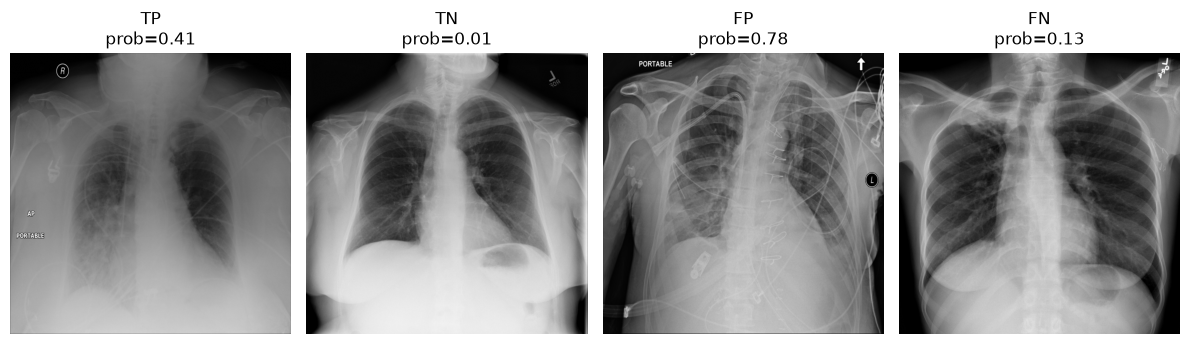

view=PA: n=2736, {'TP': 160, 'TN': 2021, 'FP': 472, 'FN': 83, 'accuracy': 0.7971491228070176, 'sensitivity': 0.6584362139917695, 'specificity': 0.8106698756518251, 'precision': 0.25316455696202533, 'f1': 0.3657142857142857}
view=AP: n=2248, {'TP': 793, 'TN': 459, 'FP': 962, 'FN': 34, 'accuracy': 0.5569395017793595, 'sensitivity': 0.9588875453446191, 'specificity': 0.3230119634060521, 'precision': 0.45185185185185184, 'f1': 0.6142525174283502}


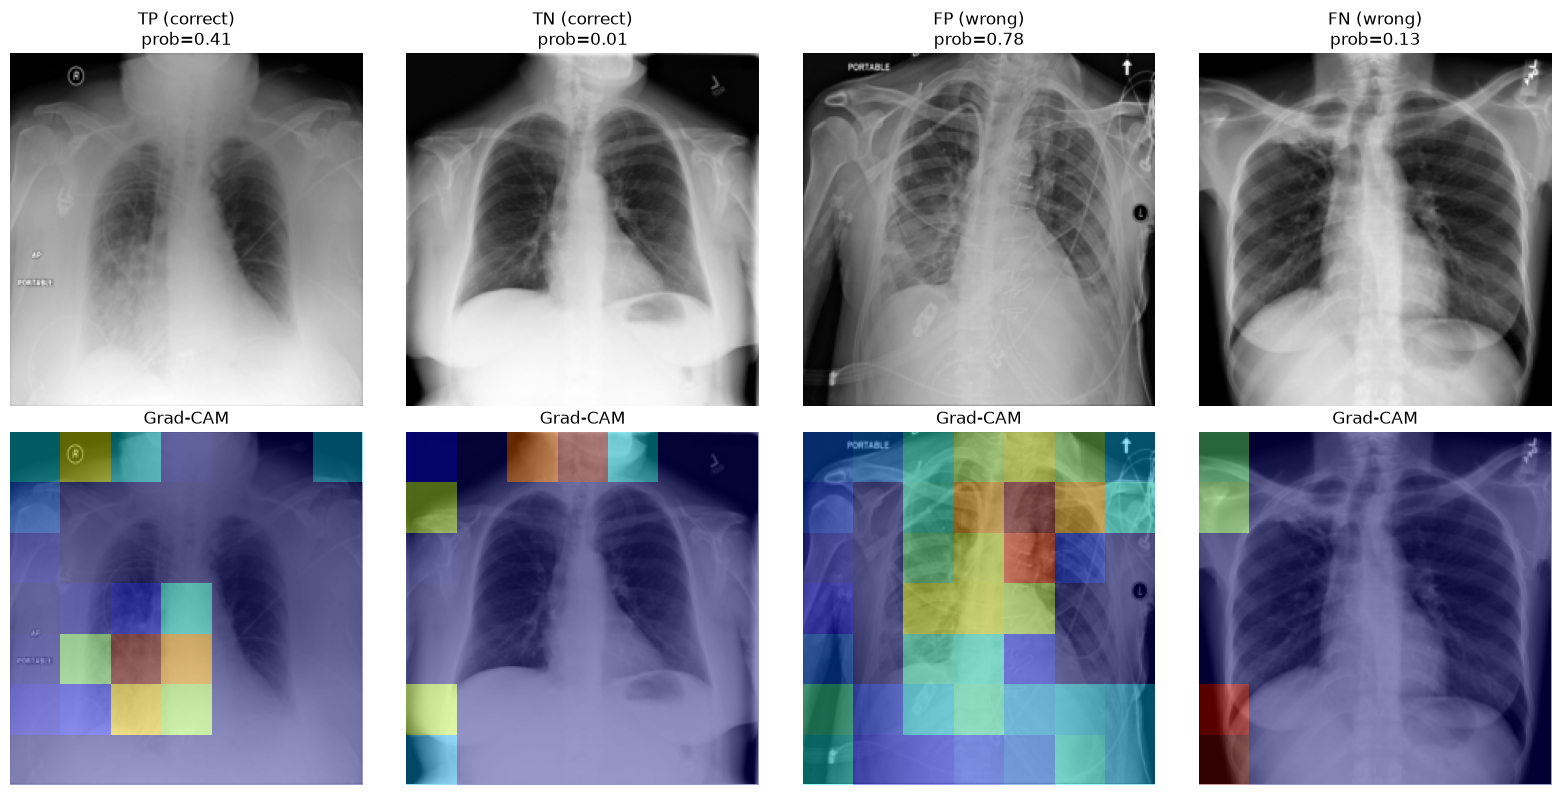

In [ ]:
# TODO: TP / TN / FP / FN examples                                        [2]
# use the screening threshold from part F to decide predicted class here
test_preds_cnn = (cnn_test_probs >= screening_threshold).astype(int)
test_labels_arr = cnn_test_labels

tp_idx = np.where((test_preds_cnn == 1) & (test_labels_arr == 1))[0]
tn_idx = np.where((test_preds_cnn == 0) & (test_labels_arr == 0))[0]
fp_idx = np.where((test_preds_cnn == 1) & (test_labels_arr == 0))[0]
fn_idx = np.where((test_preds_cnn == 0) & (test_labels_arr == 1))[0]

# same list-of-tuples pattern used in part B for the split summary
example_list = [("TP", tp_idx[0]), ("TN", tn_idx[0]), ("FP", fp_idx[0]), ("FN", fn_idx[0])]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
for ax, (name, idx) in zip(axes, example_list):
    pid = test_df.iloc[idx]["patientId"]
    img = pydicom.dcmread(id_to_path[pid]).pixel_array.astype(np.float32)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{name}\nprob={cnn_test_probs[idx]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()


# TODO: subgroup performance (e.g. AP vs PA, sex) with subgroup sizes     [2]
def get_view_position(path):
    dcm = pydicom.dcmread(path, stop_before_pixels=True)
    return getattr(dcm, "ViewPosition", None)

test_view_positions = [get_view_position(id_to_path[pid]) for pid in test_df["patientId"]]
test_df_view = test_df.copy()
test_df_view["view_position"] = test_view_positions
test_df_view["cnn_prob"] = cnn_test_probs

for view in test_df_view["view_position"].unique():
    subgroup = test_df_view[test_df_view["view_position"] == view]
    subgroup_metrics = metrics_from_probs(
        subgroup["Target"].values, subgroup["cnn_prob"].values, threshold=screening_threshold
    )
    print(f"view={view}: n={len(subgroup)}, {subgroup_metrics}")



# TODO: Grad-CAM on ≥4 images (≥1 correct, ≥1 wrong); name the target layer and justify it   [3]
# target layer: model.layer4 (the final convolutional block before global
# pooling: same block fine-tuned in E2, and the standard Grad-CAM choice
# for ResNet since it holds the last spatial feature maps before flattening)

activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

handle_f = model.layer4.register_forward_hook(forward_hook)
handle_b = model.layer4.register_full_backward_hook(backward_hook)

def get_gradcam(model, image_tensor):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad_(True)

    logit = model(image_tensor).squeeze()
    model.zero_grad()
    logit.backward()

    act = activations["value"][0]       # shape (channels, h, w)
    grad = gradients["value"][0]        # shape (channels, h, w)

    weights = grad.mean(dim=(1, 2))     # average gradient per channel
    cam = torch.zeros(act.shape[1:], device=act.device)
    for c in range(act.shape[0]):
        cam += weights[c] * act[c]
    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy(), torch.sigmoid(logit).item()

# same 4 examples as the TP/TN/FP/FN panel above (2 correct, 2 incorrect)
gradcam_list = [("TP (correct)", tp_idx[0]), ("TN (correct)", tn_idx[0]),
                 ("FP (wrong)", fp_idx[0]), ("FN (wrong)", fn_idx[0])]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (name, idx) in enumerate(gradcam_list):
    image_tensor, _ = test_dataset[idx]
    cam, prob = get_gradcam(model, image_tensor)

    axes[0, col].imshow(image_tensor.squeeze(), cmap="gray")
    axes[0, col].set_title(f"{name}\nprob={prob:.2f}")
    axes[0, col].axis("off")

    axes[1, col].imshow(image_tensor.squeeze(), cmap="gray")
    axes[1, col].imshow(cam, cmap="jet", alpha=0.4, extent=(0, IMG_SIZE, IMG_SIZE, 0))
    axes[1, col].set_title("Grad-CAM")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

handle_f.remove()
handle_b.remove()

### G4. Lung regions or shortcuts (borders, markers, artefacts)? [3]
*TODO. Grad-CAM supports inspection but does not prove causation.*